In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import ot
import pandas as pd
import time
import random
from gwgraphs import *
from scipy.stats import ttest_ind

In [2]:
np.random.seed(42)
random.seed(42)

In [3]:
# Read and Process Graph Data #
def read_graph_data():
  # Read the adjacency matrix (edges)
  with open("IMDB-BINARY_A.txt", "r") as f:
      edges = [tuple(map(int, line.split(','))) for line in f]

  # Read graph indicators
  with open("IMDB-BINARY_graph_indicator.txt", "r") as f:
      graph_indicators = [int(line.strip()) for line in f if line.strip()]

  # Read graph labels
  with open("IMDB-BINARY_graph_labels.txt", "r") as f:
      graph_labels = [int(line.strip()) for line in f]

  return edges, graph_indicators, graph_labels


def construct_networkx_graph(edges, graph_indicators, graph_labels):
  graphs = {}
  for node_id, graph_id in enumerate(graph_indicators, start=1):
      if graph_id not in graphs:
          graphs[graph_id] = nx.Graph(label=graph_labels[graph_id - 1])

  for edge in edges:
      node1, node2 = edge
      graph_id = graph_indicators[
          node1 - 1]  # Determine which graph the edge belongs to
      graphs[graph_id].add_edge(node1, node2)

  return graphs


def compute_distance_matrix(graph):
  num_nodes = len(graph.nodes)
  distance_matrix = np.full((num_nodes, num_nodes), 10000.0)

  # Get the correct node indices to be used for indexing the matrix
  node_list = list(graph.nodes())
  node_index = {node: i for i, node in enumerate(node_list)}

  for node in graph.nodes:
      lengths = nx.shortest_path_length(graph, source=node, weight="weight")

      for target, length in lengths.items():
          if target in node_index:
              distance_matrix[node_index[node], node_index[target]] = length

  return distance_matrix


def compute_averages(graphs):
  # Initialize variables
  total_nodes = 0
  class_nodes = {}
  class_counts = {}
  # Iterate through graphs to compute totals
  for graph_id, graph in graphs.items():
      num_nodes = graph.number_of_nodes()
      total_nodes += num_nodes

      # Get the class label for the current graph
      graph_label = graph.graph['label']

      if graph_label not in class_nodes:
          class_nodes[graph_label] = 0
          class_counts[graph_label] = 0

      class_nodes[graph_label] += num_nodes
      class_counts[graph_label] += 1
  # Calculate total average
  total_avg = round(total_nodes / len(graphs))

  # Calculate class-based averages
  class_averages = {label: round(class_nodes[label] / count)
                    for label, count in class_counts.items()}

  return total_avg, class_averages

In [4]:
edges, graph_indicators, graph_labels = read_graph_data()
graphs = construct_networkx_graph(edges, graph_indicators, graph_labels)
for graph_id, graph in graphs.items():
    print(
        f"Graph ID: {graph_id}, number of nodes: {graph.number_of_nodes()}, label: {graph.graph['label']}"
        )
total_avg, class_averages = compute_averages(graphs)
print(f"Average number of nodes in entire dataset: {total_avg}")
print("Average number of nodes for each class:")
for class_label, avg_nodes in class_averages.items():
        print(f"  Class {class_label}: {avg_nodes}")

Graph ID: 1, number of nodes: 20, label: 0
Graph ID: 2, number of nodes: 32, label: 0
Graph ID: 3, number of nodes: 21, label: 0
Graph ID: 4, number of nodes: 35, label: 0
Graph ID: 5, number of nodes: 14, label: 0
Graph ID: 6, number of nodes: 63, label: 0
Graph ID: 7, number of nodes: 12, label: 0
Graph ID: 8, number of nodes: 15, label: 0
Graph ID: 9, number of nodes: 18, label: 0
Graph ID: 10, number of nodes: 12, label: 0
Graph ID: 11, number of nodes: 12, label: 0
Graph ID: 12, number of nodes: 20, label: 0
Graph ID: 13, number of nodes: 13, label: 0
Graph ID: 14, number of nodes: 20, label: 0
Graph ID: 15, number of nodes: 72, label: 0
Graph ID: 16, number of nodes: 20, label: 0
Graph ID: 17, number of nodes: 18, label: 0
Graph ID: 18, number of nodes: 12, label: 0
Graph ID: 19, number of nodes: 19, label: 0
Graph ID: 20, number of nodes: 46, label: 0
Graph ID: 21, number of nodes: 30, label: 0
Graph ID: 22, number of nodes: 24, label: 0
Graph ID: 23, number of nodes: 22, label:

In [5]:
graphs_list = []
labels_list = []
for graph_id, graph in graphs.items():
    # Add the graph object to the list
    graphs_list.append(graph)

    # Extract the label and add to the label list
    label = graph.graph['label']
    # Convert label 0 to -1
    if label == 0:
        label = -1
    labels_list.append(label)

# Convert graphs into pairwise distance matrices
distance_matrices = [compute_distance_matrix(graph) for graph in graphs_list]

# Determine number of elements of each class
print("Elements of Class 1: ", labels_list.count(1))
print("Elements of Class -1: ", labels_list.count(-1))

Elements of Class 1:  500
Elements of Class -1:  500


In [6]:
# GW Distances Scatterplots #
# Normalize the matrices
Ms = []
for matrix in distance_matrices:
    Ms.append(matrix / np.max(matrix))

N=1000
heights = [
    np.full(len(graph), 1 / len(graph)) for graph in graphs_list
]
gw = np.zeros((N,N))

# Track negative values during computation
negative_count = 0
negative_pairs = []

for i in range(N):
    for j in range(i+1,N):
        tmp = ot.gromov.gromov_wasserstein2(Ms[i],Ms[j],heights[i],heights[j],loss_fun="square_loss",log=True)
        gw_value = tmp[0]
        gw[i,j] = gw_value
        
        # Check for negative values
        if gw_value < 0:
            negative_count += 1
            negative_pairs.append((i, j, gw_value))
            print(f"Negative GW distance found: graphs {i} and {j}, value: {gw_value}")
        
        # Check for NaN values
        if np.isnan(gw_value):
            print(f"NaN GW distance found: graphs {i} and {j}")
        
        #Ps_gw[i,j] = tmp[1]["T"]

# Handle negative values by taking absolute value before sqrt
gw_abs = np.abs(gw)
gw = np.sqrt(gw_abs)
gw += gw.T

print(f"\nGW computation summary:")
print(f"Total negative values found: {negative_count}")
print(f"Min GW value: {np.min(gw[gw != 0])}")
print(f"Max GW value: {np.max(gw)}")
print(f"Number of NaN values: {np.sum(np.isnan(gw))}")

# Print first few negative pairs if any
if negative_pairs:
    print(f"\nFirst 5 negative pairs:")
    for i, (idx_i, idx_j, val) in enumerate(negative_pairs[:5]):
        print(f"  Pair {i+1}: graphs {idx_i} and {idx_j}, value: {val}")

Negative GW distance found: graphs 37 and 58, value: -9.020562075079397e-17
Negative GW distance found: graphs 37 and 89, value: -6.591949208711867e-17
Negative GW distance found: graphs 37 and 91, value: -9.020562075079397e-17
Negative GW distance found: graphs 37 and 95, value: -9.367506770274758e-17
Negative GW distance found: graphs 37 and 165, value: -3.469446951953614e-17
Negative GW distance found: graphs 37 and 210, value: -9.367506770274758e-17
Negative GW distance found: graphs 37 and 241, value: -9.367506770274758e-17
Negative GW distance found: graphs 37 and 264, value: -9.367506770274758e-17
Negative GW distance found: graphs 37 and 340, value: -9.367506770274758e-17
Negative GW distance found: graphs 37 and 378, value: -1.1449174941446927e-16
Negative GW distance found: graphs 37 and 407, value: -8.673617379884035e-17
Negative GW distance found: graphs 37 and 430, value: -1.3877787807814457e-17
Negative GW distance found: graphs 37 and 509, value: -6.591949208711867e-17
N

In [7]:
### WHY NEGATIVE DISTANCES? ###
def check_graph_isomorphism(graph1, graph2):
    """Check if two graphs are isomorphic, considering both structure and node labels."""
    # First check structural isomorphism
    if not nx.is_isomorphic(graph1, graph2):
        return False, "Not structurally isomorphic"
    
    # If structurally isomorphic, check if node labels match
    def node_match(n1, n2):
        return n1.get('label', None) == n2.get('label', None)
    
    if nx.is_isomorphic(graph1, graph2, node_match=node_match):
        return True, "Isomorphic with matching node labels"
    else:
        return True, "Structurally isomorphic but different node labels"

print(f"\n=== ISOMORPHISM ANALYSIS FOR NEGATIVE GW PAIRS ===")
if negative_pairs:
    print(f"Analyzing {len(negative_pairs)} pairs with negative GW distances...\n")
    
    isomorphic_count = 0
    structural_iso_count = 0
    same_label_count = 0
    different_label_count = 0
    
    for idx, (i, j, gw_value) in enumerate(negative_pairs):
        graph1 = graphs_list[i]
        graph2 = graphs_list[j]
        
        is_iso, iso_type = check_graph_isomorphism(graph1, graph2)
        
        # Check if classification labels are the same
        label1 = labels_list[i]
        label2 = labels_list[j]
        same_label = label1 == label2
        
        if same_label:
            same_label_count += 1
            label_status = "Same classification label"
        else:
            different_label_count += 1
            label_status = "Different classification labels"
        
        print(f"Pair {idx+1}: Graphs {i} and {j} (GW distance: {gw_value})")
        print(f"  Nodes: {graph1.number_of_nodes()} vs {graph2.number_of_nodes()}")
        print(f"  Edges: {graph1.number_of_edges()} vs {graph2.number_of_edges()}")
        print(f"  Graph labels: {graph1.graph['label']} vs {graph2.graph['label']}")
        print(f"  Classification labels: {label1} vs {label2} ({label_status})")
        print(f"  Isomorphism: {iso_type}")
        
        if "Isomorphic with matching" in iso_type:
            isomorphic_count += 1
        elif "Structurally isomorphic" in iso_type:
            structural_iso_count += 1
        
        print()
    
    print(f"SUMMARY:")
    print(f"  Total negative pairs: {len(negative_pairs)}")
    print(f"  Pairs with same classification label: {same_label_count}")
    print(f"  Pairs with different classification labels: {different_label_count}")
    print(f"  Fully isomorphic (structure + labels): {isomorphic_count}")
    print(f"  Structurally isomorphic only: {structural_iso_count}")
    print(f"  Not isomorphic: {len(negative_pairs) - isomorphic_count - structural_iso_count}")
else:
    print("No negative GW distances found.")


=== ISOMORPHISM ANALYSIS FOR NEGATIVE GW PAIRS ===
Analyzing 616 pairs with negative GW distances...

Pair 1: Graphs 37 and 58 (GW distance: -9.020562075079397e-17)
  Nodes: 12 vs 12
  Edges: 36 vs 36
  Graph labels: 0 vs 0
  Classification labels: -1 vs -1 (Same classification label)
  Isomorphism: Isomorphic with matching node labels

Pair 2: Graphs 37 and 89 (GW distance: -6.591949208711867e-17)
  Nodes: 12 vs 12
  Edges: 36 vs 36
  Graph labels: 0 vs 0
  Classification labels: -1 vs -1 (Same classification label)
  Isomorphism: Isomorphic with matching node labels

Pair 3: Graphs 37 and 91 (GW distance: -9.020562075079397e-17)
  Nodes: 12 vs 12
  Edges: 36 vs 36
  Graph labels: 0 vs 0
  Classification labels: -1 vs -1 (Same classification label)
  Isomorphism: Isomorphic with matching node labels

Pair 4: Graphs 37 and 95 (GW distance: -9.367506770274758e-17)
  Nodes: 12 vs 12
  Edges: 36 vs 36
  Graph labels: 0 vs 0
  Classification labels: -1 vs -1 (Same classification label)
  

In [8]:
### Compare all graphs in dataset to determine which are isomorphic ###
# Check for isomorphic graphs
isomorphic_pairs = []
same_label_count = 0
neg_one_pairs = 0
pos_one_pairs = 0

for i in range(N):
    for j in range(i + 1, N):
        if check_graph_isomorphism(graphs_list[i], graphs_list[j])[0]:
            isomorphic_pairs.append((i, j))
            print(f"Graphs {i} and {j} are isomorphic.")
            print(
                f"  Graph {i} has {graphs_list[i].number_of_nodes()} nodes and {graphs_list[i].number_of_edges()} edges."
            )
            print(
                f"  Graph {j} has {graphs_list[j].number_of_nodes()} nodes and {graphs_list[j].number_of_edges()} edges."
            )
            print(
                f"  Classification labels: {labels_list[i]} vs {labels_list[j]}"
            )
            tmp = ot.gromov.gromov_wasserstein2(Ms[i],Ms[j],heights[i],heights[j],loss_fun="square_loss",log=True)
            print(f"  GW Distance between Graph {i} and Graph {j}: {np.sqrt(np.abs(tmp[0]))}")
            if labels_list[i] == labels_list[j]:
                same_label_count += 1
                print("Same classification label.")
            if labels_list[i] == 1 and labels_list[j] == 1:
                pos_one_pairs += 1
                print("Both graphs have label 1.")
            if labels_list[i] == -1 and labels_list[j] == -1:
                neg_one_pairs += 1
                print("Both graphs have label -1.")
            print()

print(f"Total number of graph pairs: {N * (N - 1) / 2}")
print(f"Total isomorphic pairs found: {len(isomorphic_pairs)}")
print(f"Pairs with same classification label: {same_label_count}")
print(f"Pairs with both graphs having label 1: {pos_one_pairs}")
print(f"Pairs with both graphs having label 0: {neg_one_pairs}")

Graphs 1 and 27 are isomorphic.
  Graph 1 has 32 nodes and 128 edges.
  Graph 27 has 32 nodes and 128 edges.
  Classification labels: -1 vs -1
  GW Distance between Graph 1 and Graph 27: 0.11267347735824966
Same classification label.
Both graphs have label -1.

Graphs 4 and 332 are isomorphic.
  Graph 4 has 14 nodes and 56 edges.
  Graph 332 has 14 nodes and 56 edges.
  Classification labels: -1 vs -1
  GW Distance between Graph 4 and Graph 332: 1.5694927001700474e-08
Same classification label.
Both graphs have label -1.

Graphs 4 and 416 are isomorphic.
  Graph 4 has 14 nodes and 56 edges.
  Graph 416 has 14 nodes and 56 edges.
  Classification labels: -1 vs -1
  GW Distance between Graph 4 and Graph 416: 1.5694927001700474e-08
Same classification label.
Both graphs have label -1.

Graphs 6 and 9 are isomorphic.
  Graph 6 has 12 nodes and 66 edges.
  Graph 9 has 12 nodes and 66 edges.
  Classification labels: -1 vs -1
  GW Distance between Graph 6 and Graph 9: 2.4675654805250037e-08
S

Within Romance class - Mean: 0.2761, Std: 0.0672
Within Action class - Mean: 0.2870, Std: 0.0777
Between classes - Mean: 0.2836, Std: 0.0693


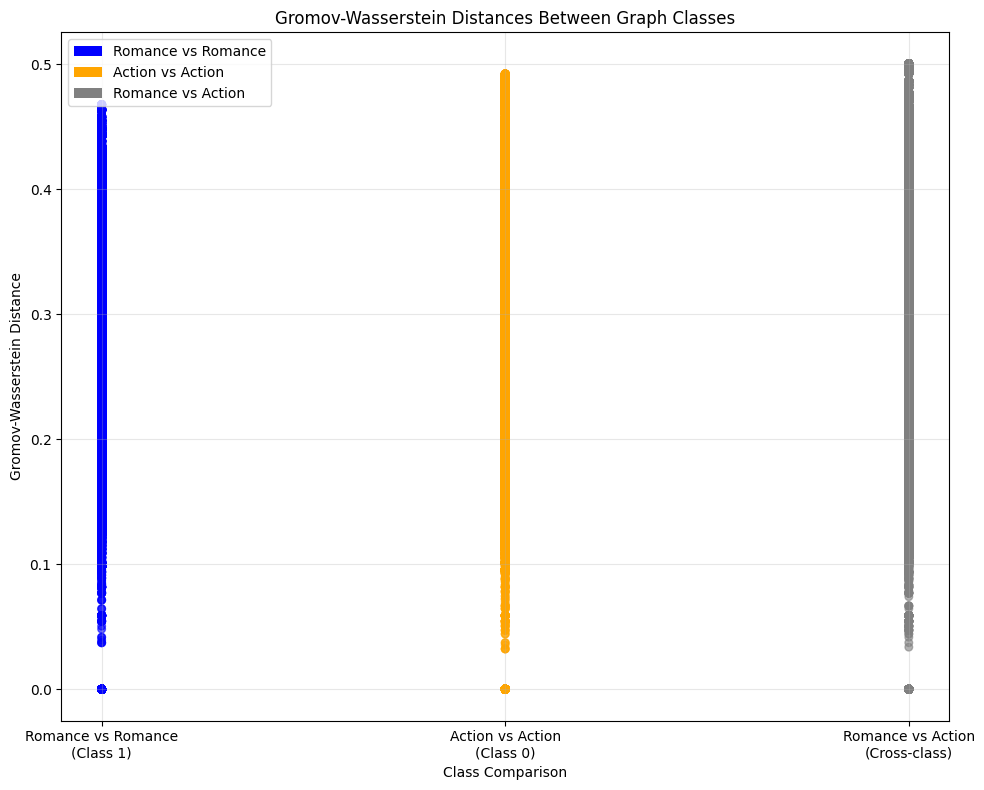

In [9]:
# Create scatterplot of GW distances by class
plt.figure(figsize=(10, 8))

# Convert labels to numpy array for easier indexing
labels_array = np.array(labels_list)

# Get indices for each class
class_1_indices = np.where(labels_array == 1)[0] 
class_minus1_indices = np.where(labels_array == -1)[0] 

# Extract GW distances for different class combinations
# Within class 1
within_class1_distances = []
for i in range(len(class_1_indices)):
    for j in range(i+1, len(class_1_indices)):
        idx_i, idx_j = class_1_indices[i], class_1_indices[j]
        within_class1_distances.append(gw[idx_i, idx_j])

# Within class -1
within_class_minus1_distances = []
for i in range(len(class_minus1_indices)):
    for j in range(i+1, len(class_minus1_indices)):
        idx_i, idx_j = class_minus1_indices[i], class_minus1_indices[j]
        within_class_minus1_distances.append(gw[idx_i, idx_j])

# Between classes
between_classes_distances = []
for i in class_1_indices:
    for j in class_minus1_indices:
        between_classes_distances.append(gw[i, j])

# Create scatter plot
x_positions = []
distances = []
colors = []
labels_plot = []

# Add within class 1 distances
x_positions.extend([0] * len(within_class1_distances))
distances.extend(within_class1_distances)
colors.extend(['blue'] * len(within_class1_distances))
labels_plot.extend(['Romance vs Romance'] * len(within_class1_distances))

# Add within class -1 distances
x_positions.extend([1] * len(within_class_minus1_distances))
distances.extend(within_class_minus1_distances)
colors.extend(['orange'] * len(within_class_minus1_distances))
labels_plot.extend(['Action vs Action'] * len(within_class_minus1_distances))

# Add between classes distances
x_positions.extend([2] * len(between_classes_distances))
distances.extend(between_classes_distances)
colors.extend(['gray'] * len(between_classes_distances))
labels_plot.extend(['Romance vs Action'] * len(between_classes_distances))

# Create the scatter plot
scatter = plt.scatter(x_positions, distances, c=colors, alpha=0.6, s=30)
# Customize the plot
plt.xlabel('Class Comparison')
plt.ylabel('Gromov-Wasserstein Distance')
plt.title('Gromov-Wasserstein Distances Between Graph Classes')
plt.xticks([0, 1, 2], ['Romance vs Romance\n(Class 1)', 'Action vs Action\n(Class 0)', 'Romance vs Action\n(Cross-class)'])
legend_elements = [Patch(facecolor='blue', label='Romance vs Romance'),
                   Patch(facecolor='orange', label='Action vs Action'),
                   Patch(facecolor='gray', label='Romance vs Action')]
plt.legend(handles=legend_elements)

# Add some statistics
print(f"Within Romance class - Mean: {np.mean(within_class1_distances):.4f}, Std: {np.std(within_class1_distances):.4f}")
print(f"Within Action class - Mean: {np.mean(within_class_minus1_distances):.4f}, Std: {np.std(within_class_minus1_distances):.4f}")
print(f"Between classes - Mean: {np.mean(between_classes_distances):.4f}, Std: {np.std(between_classes_distances):.4f}")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# Perform statistical test
active_vs_inactive_mean = np.mean(between_classes_distances)
within_active_mean = np.mean(within_class1_distances)
within_inactive_mean = np.mean(within_class_minus1_distances)

print(f"\nStatistical Summary:")
print(f"Number of Romance graphs: {len(class_1_indices)}")
print(f"Number of Action graphs: {len(class_minus1_indices)}")
print(f"Number of within-Romance comparisons: {len(within_class1_distances)}")
print(f"Number of within-Action comparisons: {len(within_class_minus1_distances)}")
print(f"Number of cross-class comparisons: {len(between_classes_distances)}")

# Test if between-class distances are significantly different from within-class distances
all_within_class = within_class1_distances + within_class_minus1_distances
t_stat, p_value = ttest_ind(between_classes_distances, all_within_class)
print(f"\nT-test (Between-class vs Within-class distances):")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Significant difference: {'Yes' if p_value < 0.05 else 'No'}")


Statistical Summary:
Number of Romance graphs: 500
Number of Action graphs: 500
Number of within-Romance comparisons: 124750
Number of within-Action comparisons: 124750
Number of cross-class comparisons: 250000

T-test (Between-class vs Within-class distances):
T-statistic: 10.3702
P-value: 0.0000
Significant difference: Yes


In [11]:
# gLGW Distances Scatterplots #

In [12]:
k_bary = 20  # use dataset average
idx_bary = []
classes = [-1,1]

for i in classes:
    # Find the indices of instances with label i
    labels_list = np.asarray(labels_list) 
    indices = np.where(labels_list == i)[0]
    if indices.size > 0:
        idx_bary.extend(np.random.choice(indices, size=min(5, len(indices)), replace=False))

# Initialize reference matrix with k_bary size
M_ref = np.zeros((k_bary, k_bary))
selected_Ms = [Ms[i] for i in idx_bary]
selected_heights = [heights[i] for i in idx_bary]
lambdas = ot.unif(len(idx_bary))

M_ref = ot.gromov.gromov_barycenters(k_bary,
                                     Cs=selected_Ms,
                                     ps=selected_heights,
                                     p=ot.unif(k_bary),
                                     lambdas=lambdas,
                                     loss_fun='square_loss',
                                     max_iter=200,
                                     tol=1e-12,
                                     random_state=42)

height_ref = ot.unif(k_bary)
lgw_matrix, lgw_time = lgw_procedure(M_ref,
                                     height_ref,
                                     None,
                                     Ms,
                                     heights,
                                     mode="graph")

In [13]:
print(f"\ngLGW computation summary:")
print(f"gLGW computation time: {lgw_time:.4f} seconds")
print(f"Min gLGW value: {np.min(lgw_matrix[lgw_matrix != 0])}")
print(f"Max gLGW value: {np.max(lgw_matrix)}")
print(f"Number of NaN values: {np.sum(np.isnan(lgw_matrix))}")

negative_lgw_count = np.sum(lgw_matrix < 0)
if negative_lgw_count > 0:
    print(f"Warning: {negative_lgw_count} negative gLGW values found!")


gLGW computation summary:
gLGW computation time: 7.2743 seconds
Min gLGW value: 0.03535533905932738
Max gLGW value: 0.6334429729659965
Number of NaN values: 0



gLGW Distance Statistics:
Within Romance class - Mean: 0.3202, Std: 0.0682
Within Action class - Mean: 0.3216, Std: 0.0781
Between classes - Mean: 0.3222, Std: 0.0710


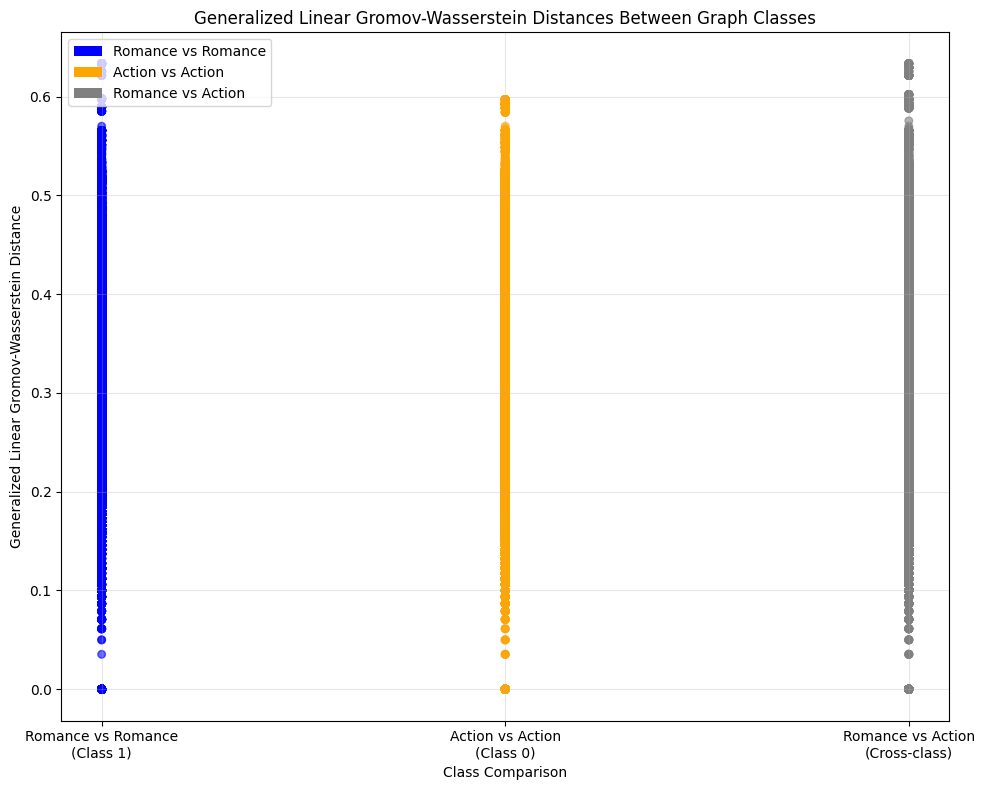

In [14]:
# Create scatterplot of gLGW distances by class
plt.figure(figsize=(10, 8))

# Convert labels to numpy array for easier indexing
labels_array = np.array(labels_list)

# Get indices for each class
class_1_indices = np.where(labels_array == 1)[0]  # Romance class
class_minus1_indices = np.where(labels_array == -1)[0]  # Action class

# Extract gLGW distances for different class combinations
# Within class 1 (Romance vs Romance)
within_class1_lgw_distances = []
for i in range(len(class_1_indices)):
    for j in range(i+1, len(class_1_indices)):
        idx_i, idx_j = class_1_indices[i], class_1_indices[j]
        within_class1_lgw_distances.append(lgw_matrix[idx_i, idx_j])

# Within class -1 (Action vs Action)
within_class_minus1_lgw_distances = []
for i in range(len(class_minus1_indices)):
    for j in range(i+1, len(class_minus1_indices)):
        idx_i, idx_j = class_minus1_indices[i], class_minus1_indices[j]
        within_class_minus1_lgw_distances.append(lgw_matrix[idx_i, idx_j])

# Between classes (Romance vs Action)
between_classes_lgw_distances = []
for i in class_1_indices:
    for j in class_minus1_indices:
        between_classes_lgw_distances.append(lgw_matrix[i, j])

# Create scatter plot
x_positions_lgw = []
distances_lgw = []
colors_lgw = []
labels_plot_lgw = []

# Add within class 1 distances
x_positions_lgw.extend([0] * len(within_class1_lgw_distances))
distances_lgw.extend(within_class1_lgw_distances)
colors_lgw.extend(['blue'] * len(within_class1_lgw_distances))
labels_plot_lgw.extend(['Romance vs Romance'] * len(within_class1_lgw_distances))

# Add within class -1 distances
x_positions_lgw.extend([1] * len(within_class_minus1_lgw_distances))
distances_lgw.extend(within_class_minus1_lgw_distances)
colors_lgw.extend(['orange'] * len(within_class_minus1_lgw_distances))
labels_plot_lgw.extend(['Action vs Action'] * len(within_class_minus1_lgw_distances))

# Add between classes distances
x_positions_lgw.extend([2] * len(between_classes_lgw_distances))
distances_lgw.extend(between_classes_lgw_distances)
colors_lgw.extend(['gray'] * len(between_classes_lgw_distances))
labels_plot_lgw.extend(['Romance vs Action'] * len(between_classes_lgw_distances))

# Create the scatter plot
scatter_lgw = plt.scatter(x_positions_lgw, distances_lgw, c=colors_lgw, alpha=0.6, s=30)

# Customize the plot
plt.xlabel('Class Comparison')
plt.ylabel('Generalized Linear Gromov-Wasserstein Distance')
plt.title('Generalized Linear Gromov-Wasserstein Distances Between Graph Classes')
plt.xticks([0, 1, 2], ['Romance vs Romance\n(Class 1)', 'Action vs Action\n(Class 0)', 'Romance vs Action\n(Cross-class)'])

# Add legend
from matplotlib.patches import Patch
legend_elements_lgw = [Patch(facecolor='blue', label='Romance vs Romance'),
                       Patch(facecolor='orange', label='Action vs Action'),
                       Patch(facecolor='gray', label='Romance vs Action')]
plt.legend(handles=legend_elements_lgw)

# Add some statistics
print(f"\ngLGW Distance Statistics:")
print(f"Within Romance class - Mean: {np.mean(within_class1_lgw_distances):.4f}, Std: {np.std(within_class1_lgw_distances):.4f}")
print(f"Within Action class - Mean: {np.mean(within_class_minus1_lgw_distances):.4f}, Std: {np.std(within_class_minus1_lgw_distances):.4f}")
print(f"Between classes - Mean: {np.mean(between_classes_lgw_distances):.4f}, Std: {np.std(between_classes_lgw_distances):.4f}")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Perform statistical test for gLGW
active_vs_inactive_lgw_mean = np.mean(between_classes_lgw_distances)
within_active_lgw_mean = np.mean(within_class1_lgw_distances)
within_inactive_lgw_mean = np.mean(within_class_minus1_lgw_distances)

print(f"\ngLGW Statistical Summary:")
print(f"Number of Romance graphs: {len(class_1_indices)}")
print(f"Number of Action graphs: {len(class_minus1_indices)}")
print(f"Number of within-Romance comparisons: {len(within_class1_lgw_distances)}")
print(f"Number of within-Action comparisons: {len(within_class_minus1_lgw_distances)}")
print(f"Number of cross-class comparisons: {len(between_classes_lgw_distances)}")

# Test if between-class gLGW distances are significantly different from within-class distances
all_within_class_lgw = within_class1_lgw_distances + within_class_minus1_lgw_distances
t_stat_lgw, p_value_lgw = ttest_ind(between_classes_lgw_distances, all_within_class_lgw)
print(f"\nT-test for LGW (Between-class vs Within-class distances):")
print(f"T-statistic: {t_stat_lgw:.4f}")
print(f"P-value: {p_value_lgw:.4f}")
print(f"Significant difference: {'Yes' if p_value_lgw < 0.05 else 'No'}")

# Additional comparison between GW and LGW results
print(f"gLGW between-class mean: {active_vs_inactive_lgw_mean:.4f}")
print(f"gLGW within-Romance mean: {within_active_lgw_mean:.4f}")
print(f"gLGW within-Action mean: {within_inactive_lgw_mean:.4f}")


gLGW Statistical Summary:
Number of Romance graphs: 500
Number of Action graphs: 500
Number of within-Romance comparisons: 124750
Number of within-Action comparisons: 124750
Number of cross-class comparisons: 250000

T-test for LGW (Between-class vs Within-class distances):
T-statistic: 6.1099
P-value: 0.0000
Significant difference: Yes
gLGW between-class mean: 0.3222
gLGW within-Romance mean: 0.3202
gLGW within-Action mean: 0.3216


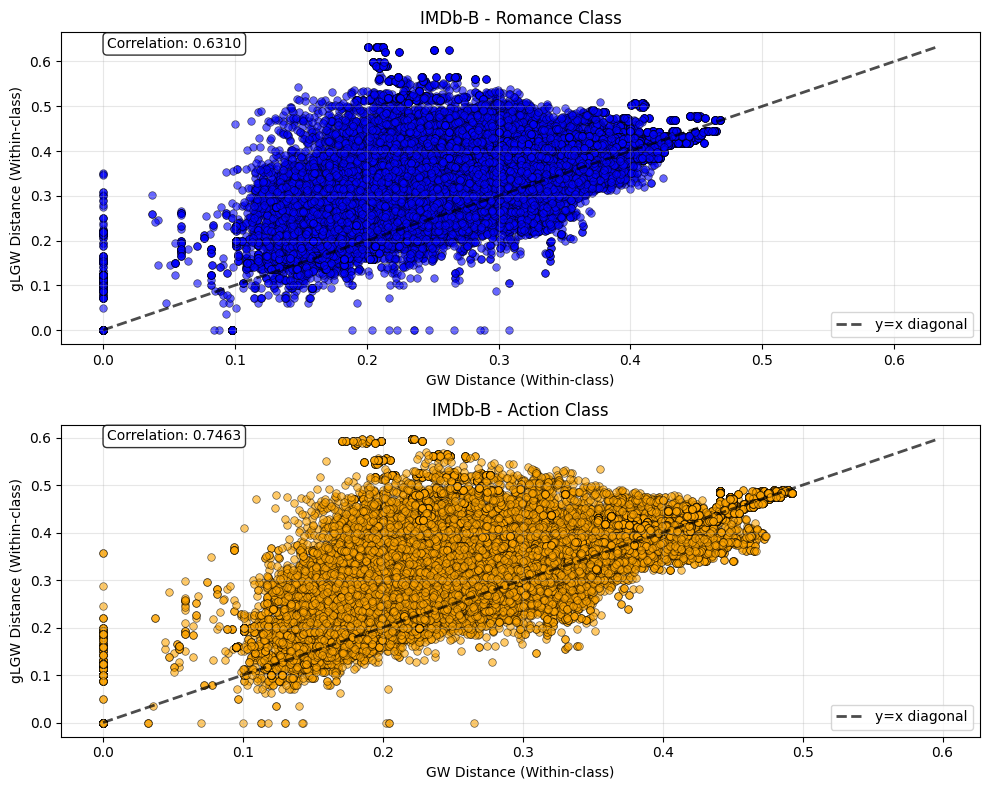

In [16]:
## 2D GW vs. gLGW comparison ##
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,8))
labels_array = np.array(labels_list)

def create_within_class_gw_vs_lgw_scatterplot(gw_matrix, lgw_matrix, labels_array, ax, title, class_label):
    """Create a 2D scatterplot comparing within-class GW vs gLGW distances for a specific class"""

    # Get indices for the specific class
    if class_label == 1:
        class_indices = np.where(labels_array == 1)[0]  
        class_name = "Romance"
        color = 'blue'
    else:
        class_indices = np.where(labels_array == -1)[0] 
        class_name = "Action"
        color = 'orange'

    # Extract within-class distances only
    gw_within_class = []
    lgw_within_class = []

    for i in range(len(class_indices)):
        for j in range(i + 1, len(class_indices)):
            idx_i, idx_j = class_indices[i], class_indices[j]
            gw_within_class.append(gw_matrix[idx_i, idx_j])
            lgw_within_class.append(lgw_matrix[idx_i, idx_j])

    # Create scatter plot
    ax.scatter(gw_within_class, lgw_within_class, alpha=0.6, s=30, color=color, 
               edgecolors='black', linewidth=0.5)

    # Add diagonal line for comparison
    if len(gw_within_class) > 0:
        min_val = min(min(gw_within_class), min(lgw_within_class))
        max_val = max(max(gw_within_class), max(lgw_within_class))
        ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.7, linewidth=2, label='y=x diagonal')

    # Customize the plot
    ax.set_xlabel('GW Distance (Within-class)')
    ax.set_ylabel('gLGW Distance (Within-class)')
    ax.set_title(f'{title} - {class_name} Class')
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Calculate correlation coefficient if there are enough points
    if len(gw_within_class) > 1:
        correlation = np.corrcoef(gw_within_class, lgw_within_class)[0, 1]
        ax.text(0.05, 0.95, f'Correlation: {correlation:.4f}', transform=ax.transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        correlation = np.nan
        ax.text(0.05, 0.95, 'Insufficient data', transform=ax.transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    return gw_within_class, lgw_within_class, correlation

# Create scatterplots for both datasets and both classes
gw_within_active_1, lgw_within_active_1, corr_active_1 = create_within_class_gw_vs_lgw_scatterplot(
    gw, lgw_matrix, labels_array, ax1, 'IMDb-B', 1
)

gw_within_inactive_1, lgw_within_inactive_1, corr_inactive_1 = create_within_class_gw_vs_lgw_scatterplot(
    gw, lgw_matrix, labels_array, ax2, 'IMDb-B', -1
)
plt.tight_layout()

In [17]:
### Distances Scatterplots: Distances from GW & fGW Barycenters of Each Class ###
# Compute the GW barycenter for each category
num_nodes = 20
seed = 42
X_class1 = [
           distance_matrices[j] for j in range(len(distance_matrices)) if labels_list[j] == -1
        ]
X_class2 = [
            distance_matrices[j] for j in range(len(distance_matrices)) if labels_list[j] == 1
        ]
barycenter_matrix_class1 = ot.gromov.gromov_barycenters(
    N=num_nodes,
    Cs=X_class1,
    loss_fun='square_loss',
    random_state=seed)
print("GW barycenter for Class 1 graphs:",
          barycenter_matrix_class1)
print("GW barycenter for Class 1 graphs computed")
barycenter_matrix_class2 = ot.gromov.gromov_barycenters(
    N=num_nodes,
    Cs=X_class2,
    loss_fun='square_loss',
    random_state=seed)
print("GW barycenter for Class 2 graphs:",
          barycenter_matrix_class2)
print("GW barycenter for Class 2 graphs computed")

GW barycenter for Class 1 graphs: [[0.3946861  1.46807323 0.88715859 1.4642391  1.08693413 1.03483037
  1.40567998 1.25026313 1.1563233  1.28647982 1.44205493 1.31586983
  1.09215498 1.17767415 1.12862639 1.44947144 1.19830604 1.43986114
  1.34099819 1.177074  ]
 [1.46807323 0.21654849 1.05676727 1.02723105 1.76235783 1.67333014
  1.4397066  1.7912301  1.78238808 1.75953099 1.18277773 1.65605712
  1.76043804 1.78177035 1.76629183 1.05069343 1.79479493 1.3203495
  1.49234139 1.80446871]
 [0.88715859 1.05676727 0.18741324 1.06239636 1.00704141 1.00371781
  1.02862254 1.03904444 0.98616405 1.04000905 1.04607981 1.03088031
  1.02996637 1.03644701 1.03301434 1.05240028 1.03429244 1.04480808
  1.01652799 1.03286483]
 [1.4642391  1.02723105 1.06239636 0.24949597 1.75394388 1.67264883
  1.42449288 1.78812296 1.78454114 1.77174046 1.24546793 1.63755996
  1.75844741 1.78776881 1.77311107 1.09361385 1.80472833 1.27381749
  1.49514402 1.79628817]
 [1.08693413 1.76235783 1.00704141 1.75394388 0.180

In [18]:
def compute_gromov_wasserstein_distance(adj_matrix1, adj_matrix2):
    """
    Compute the Gromov-Wasserstein distance between two adjacency matrices.
    
    Args:
        adj_matrix1: First adjacency matrix
        adj_matrix2: Second adjacency matrix
    
    Returns:
        The Gromov-Wasserstein distance
    """
    n1, n2 = adj_matrix1.shape[0], adj_matrix2.shape[0]
    
    # Create uniform distributions
    p = np.ones(n1) / n1
    q = np.ones(n2) / n2
    
    # Compute Gromov-Wasserstein distance
    gw_dist = np.abs(ot.gromov.gromov_wasserstein2(adj_matrix1, adj_matrix2, p, q, 'square_loss'))
    
    return np.sqrt(gw_dist)

In [19]:
# Distances from each class to each barycenter
gw_distances_from_negone_to_negonebary = []
gw_distances_from_one_to_negonebary = []
gw_distances_from_negone_to_onebary = []
gw_distances_from_one_to_onebary = []

for j in range(len(distance_matrices)):
    if labels_list[j] == -1:
        dist_negone = compute_gromov_wasserstein_distance(distance_matrices[j], barycenter_matrix_class1)
        dist_one = compute_gromov_wasserstein_distance(distance_matrices[j], barycenter_matrix_class2)
        gw_distances_from_negone_to_negonebary.append(dist_negone)
        gw_distances_from_negone_to_onebary.append(dist_one)
    else:
        dist_negone = compute_gromov_wasserstein_distance(distance_matrices[j], barycenter_matrix_class1)
        dist_one = compute_gromov_wasserstein_distance(distance_matrices[j], barycenter_matrix_class2)
        gw_distances_from_one_to_negonebary.append(dist_negone)
        gw_distances_from_one_to_onebary.append(dist_one)

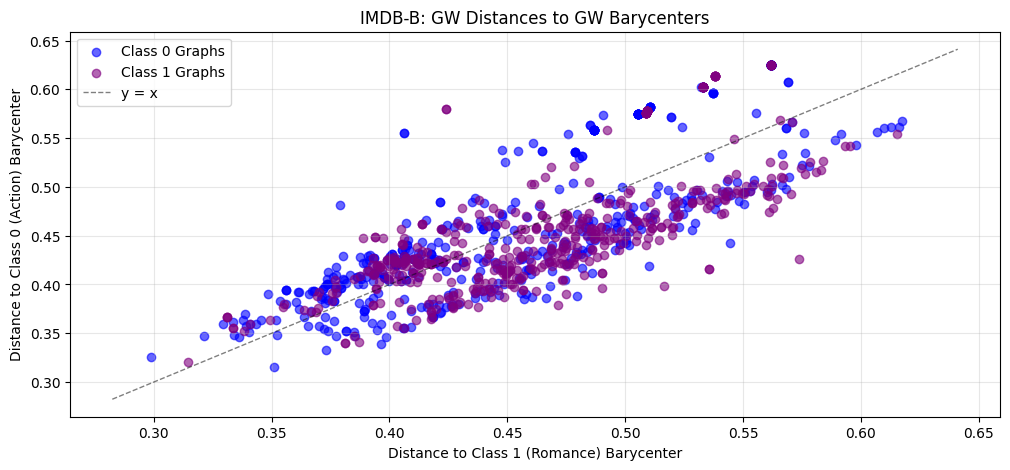

In [20]:
# Plot results
distances = (gw_distances_from_negone_to_negonebary + gw_distances_from_one_to_negonebary + 
            gw_distances_from_negone_to_onebary + gw_distances_from_one_to_onebary)
min_dist = min(distances)
max_dist = max(distances)
margin = (max_dist - min_dist) * 0.05  # Add 5% margin

axis_min = min_dist - margin
axis_max = max_dist + margin

plt.figure(figsize=(12, 5))
plt.scatter(gw_distances_from_negone_to_negonebary, gw_distances_from_negone_to_onebary, 
           alpha=0.6, label='Class 0 Graphs', color='blue')
plt.scatter(gw_distances_from_one_to_negonebary, gw_distances_from_one_to_onebary, 
           alpha=0.6, label='Class 1 Graphs', color='purple')
# Add diagonal line
plt.plot([axis_min, axis_max], [axis_min, axis_max],'k--', alpha=0.5, linewidth=1, label='y = x')
plt.xlabel('Distance to Class 1 (Romance) Barycenter')
plt.ylabel('Distance to Class 0 (Action) Barycenter')
plt.title('IMDB-B: GW Distances to GW Barycenters')
plt.legend()
plt.grid(True, alpha=0.3)